In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
import seaborn as sns

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [3]:
from astropy.io import fits
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

In [4]:
twoprocess_df = fits_to_pandas("../../data/astroNN_2proc_crossmatch.fits", hdu=2)
astronn_df = fits_to_pandas("../../data/astroNN_2proc_crossmatch.fits", hdu=1)
adrian_df = fits_to_pandas("../../data/allStar-dr17-synspec_rev1-GaiaDR3-EDR3_STARHORSE_v2-MilkyWayPotential2022-staeckel.fits")
astronn_df['MG_FE'] = astronn_df['MG_H'] - astronn_df['FE_H']
twoprocess_df['A_CC/A_IA'] = twoprocess_df['A_CC']/twoprocess_df['A_IA']
twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] > 0]
#twoprocess_df = twoprocess_df[twoprocess_df['A_CC/A_IA'] < 10]

data = (
    adrian_df
    .merge(twoprocess_df, on="APOGEE_ID", how="inner")
    .merge(astronn_df, on="APOGEE_ID", how="inner")
)

data = data.dropna()

#data['A_CC/A_IA'] = data['A_CC']/data['A_IA']
data['A_IA/A_CC'] = data['A_IA']/data['A_CC']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "red"
data_low_alpha['color'] = "blue"

merged = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

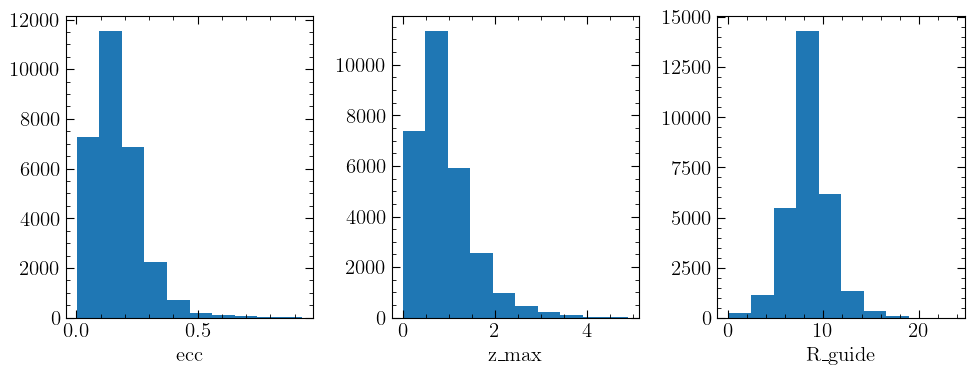

In [5]:
plt.figure(figsize=(10,4))

merged = merged[merged['z_max'] < 5]

plt.subplot(1,3,1)
plt.hist(merged['ecc'])
plt.xlabel('ecc')
mean_ecc = np.mean(merged['ecc'])
std_ecc = np.std(merged['ecc'])



plt.subplot(1,3,2)
plt.hist(merged['z_max'])
plt.xlabel("z_max")
mean_zmax = np.mean(merged['z_max'])
std_zmax = np.std(merged['z_max'])


plt.subplot(1,3,3)
plt.hist(merged['R_guide'])
plt.xlabel("R_guide")
mean_rguide = np.mean(merged['R_guide'])
std_rguide = np.std(merged['R_guide'])



plt.tight_layout()

In [6]:
bin_edges = np.arange(0, 12, 1)  # 0,1,2,...,10

merged['R_guide_bin'] = pd.cut(merged['R_guide'], bins=bin_edges, right=False, labels=False)

In [7]:
circ_ones = merged[merged['ecc'] < 0.2]

bin_9 = circ_ones[circ_ones['R_guide_bin'] == 9]

bin_r_g = bin_9

mask_high_fe_mg = (bin_r_g['FE_MG'] < 0) & (bin_r_g['FE_MG'] > -0.05)
mask_low_fe_mg = (bin_r_g['FE_MG'] < -0.05) & (bin_r_g['FE_MG'] > -0.10)
mask_high_fe_h = (bin_r_g['FE_H'] < 0.2) & (bin_r_g['FE_H'] > 0)
mask_low_fe_h = (bin_r_g['FE_H'] < 0) & (bin_r_g['FE_H'] > -0.2)

# High [Fe/Mg]
between -0.05 and 0

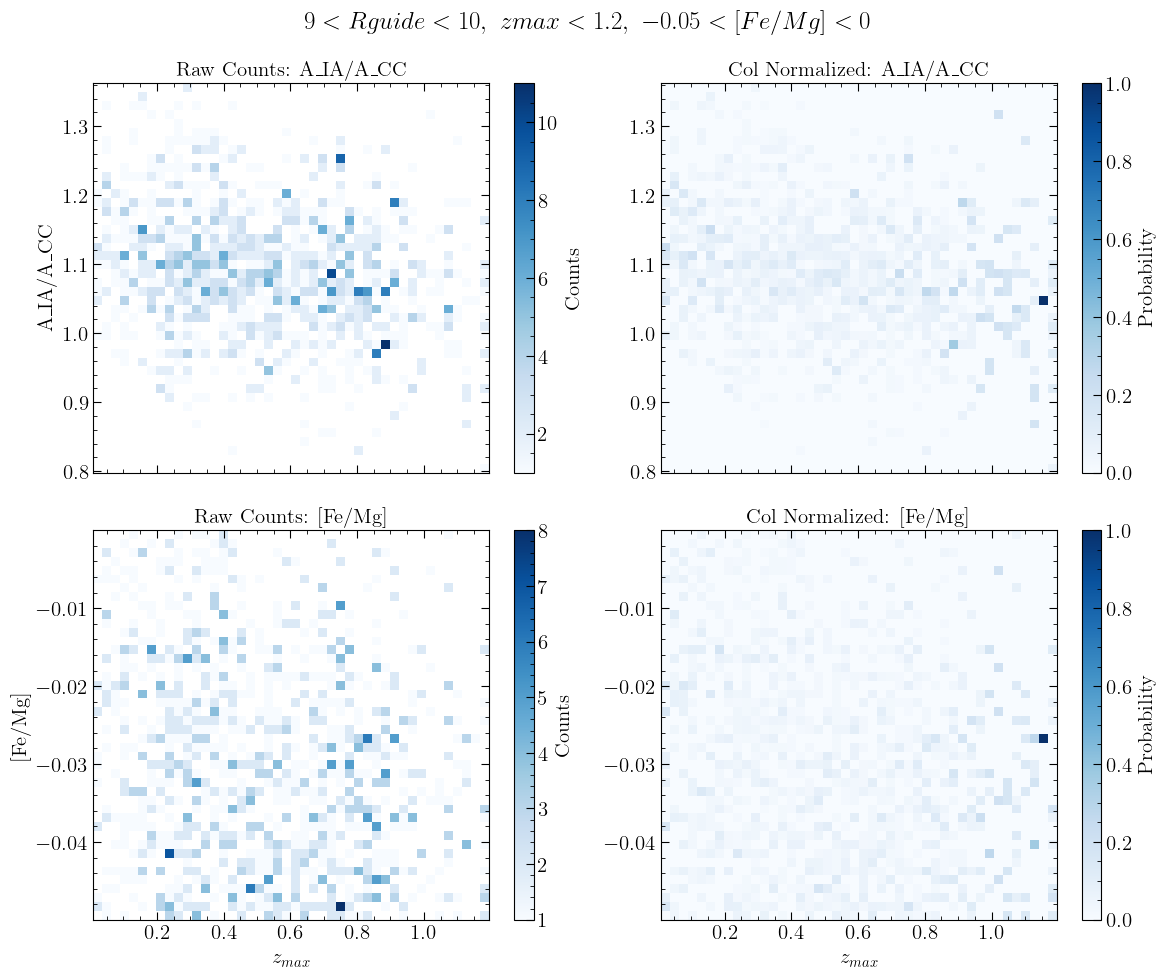

In [13]:
bin_plot = bin_r_g[mask_high_fe_mg]
bin_plot = bin_plot[bin_plot['z_max'] < 1.2]

# Setup
n_bins = 45
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='Blues')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, \ zmax < 1.2, \ -0.05 < [Fe/Mg] < 0 $")
plt.tight_layout()
plt.savefig('plots/binned_on_met/bin_9_2d_highfemg.png', dpi=300)
plt.show()

# Low [Fe/Mg]

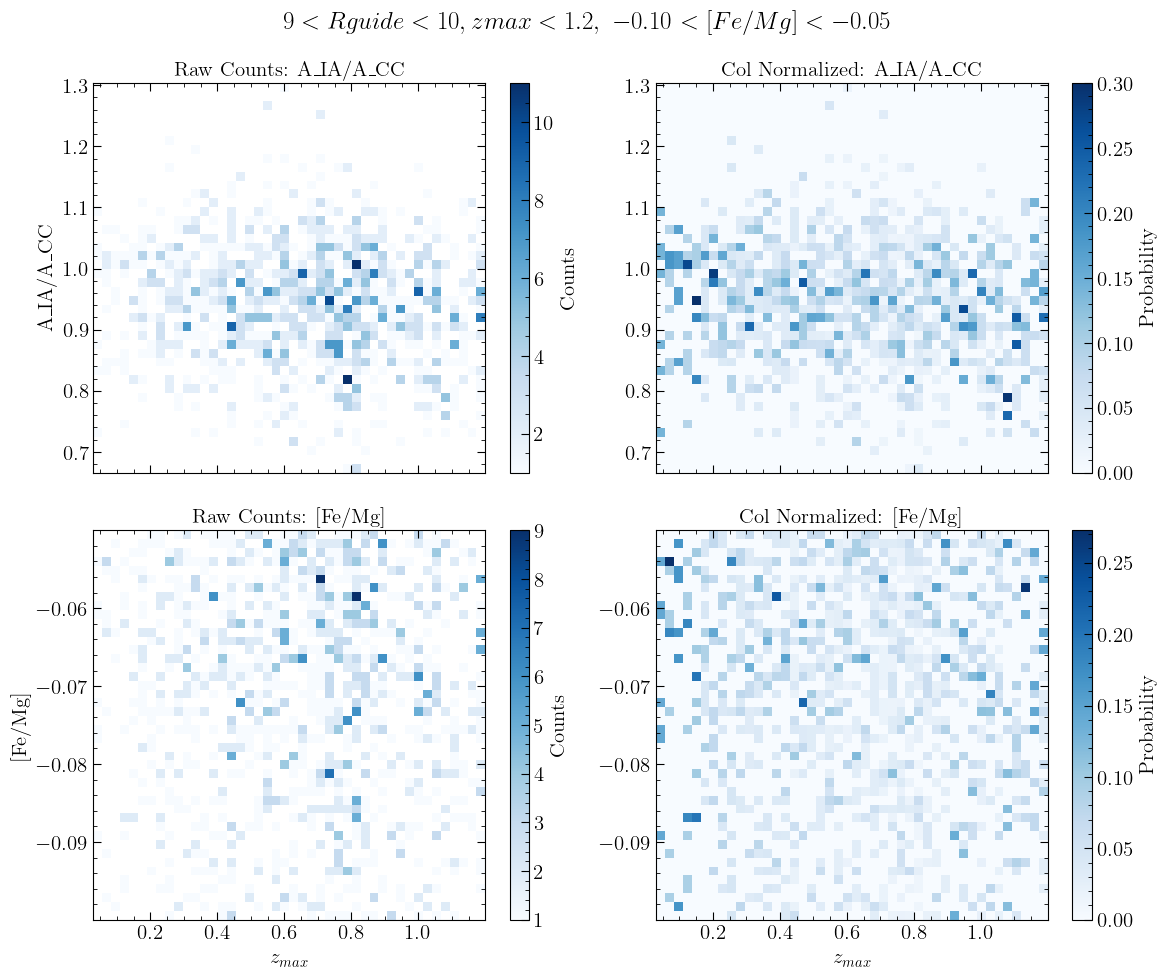

In [14]:
bin_plot = bin_r_g[mask_low_fe_mg]
bin_plot = bin_plot[bin_plot['z_max'] < 1.2]

# Setup
n_bins = 45
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='Blues')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, zmax < 1.2, \ -0.10 < [Fe/Mg] < -0.05 $")
plt.tight_layout()
plt.savefig('plots/binned_on_met/bin_9_2d_lowfemg.png', dpi=300)
plt.show()

# High [Fe/H]

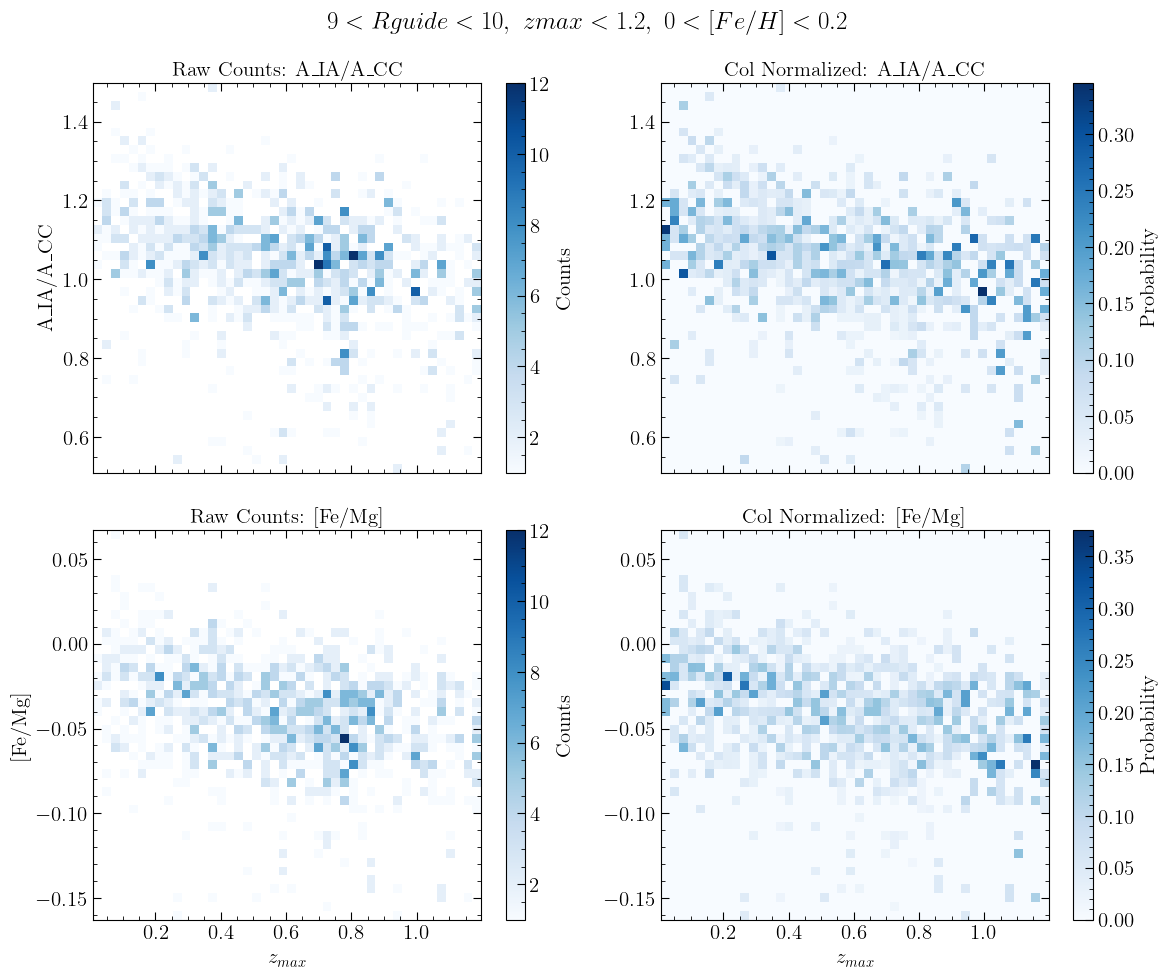

In [15]:
bin_plot = bin_r_g[mask_high_fe_h]
bin_plot = bin_plot[bin_plot['z_max'] < 1.2]

# Setup
n_bins = 45
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='Blues')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, \ zmax < 1.2, \ 0 < [Fe/H] < 0.2$")
plt.tight_layout()
plt.savefig('plots/binned_on_met/bin_9_2d_highfe_h.png', dpi=300)
plt.show()

# Low [Fe/H]

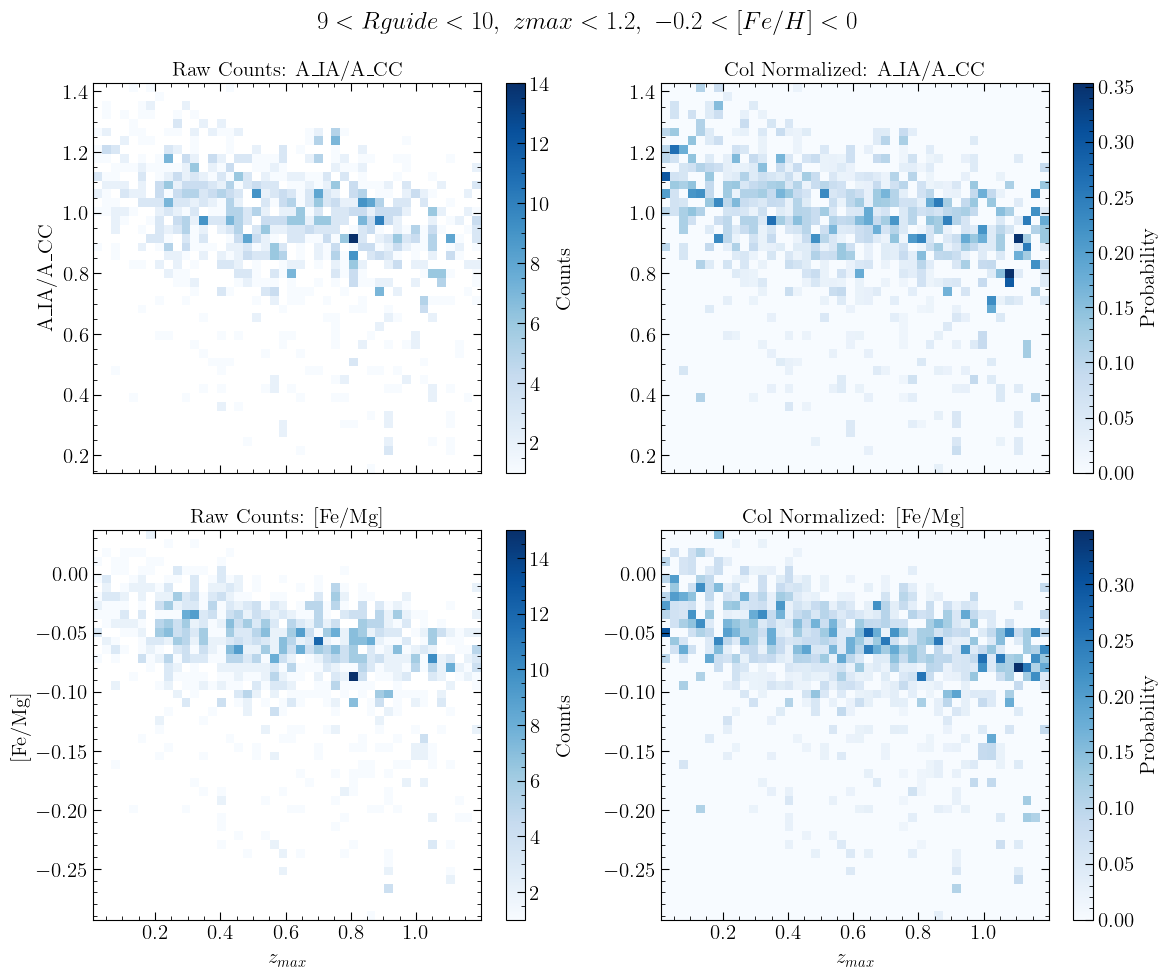

In [16]:
bin_plot = bin_r_g[mask_low_fe_h]
bin_plot = bin_plot[bin_plot['z_max'] < 1.2]

# Setup
n_bins = 45
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='Blues')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, \ zmax < 1.2, \ -0.2 < [Fe/H] < 0$")
plt.tight_layout()
plt.savefig('plots/binned_on_met/bin_9_2d_low_feh.png', dpi=300)
plt.show()

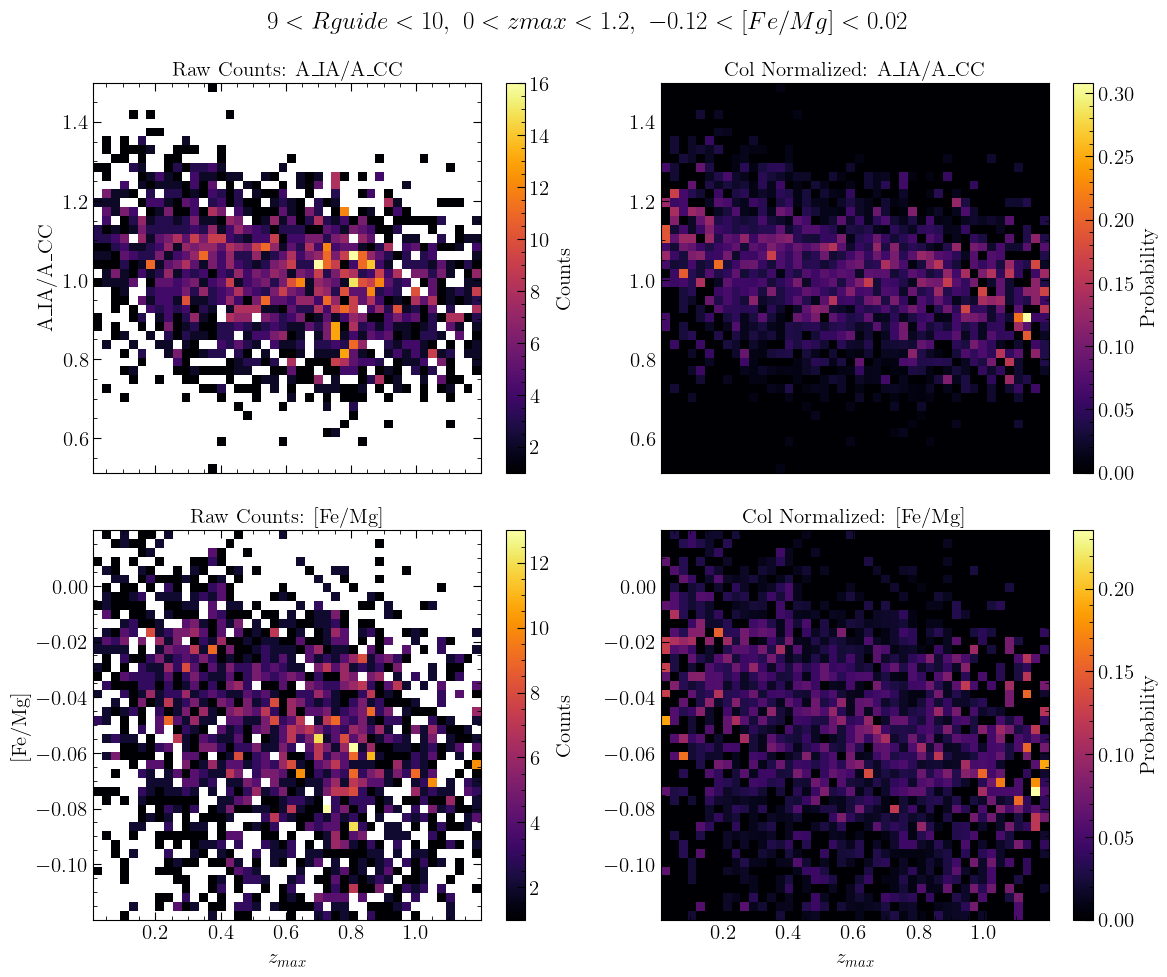

In [17]:
#bin_plot = bin_9[mask_low_fe_h]
bin_plot = bin_r_g
box = (bin_plot['z_max'] < 1.2) & (bin_plot['z_max'] > 0) & (bin_plot['FE_MG'] > -0.12) & (bin_plot['FE_MG'] < 0.02)
#bin_plot = bin_plot[bin_plot['z_max'] < 1.1]
bin_plot = bin_plot[box]

# Setup
n_bins = 45
x_data = bin_plot['z_max']
x_bins = np.linspace(x_data.min(), x_data.max(), n_bins)

# Define Y variables
y_vars = [
    {'data': bin_plot['A_IA/A_CC'], 'label': 'A_IA/A_CC'},
    {'data': bin_plot['FE_MG'],     'label': '[Fe/Mg]'}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for row_idx, y_info in enumerate(y_vars):
    y_data = y_info['data']
    label = y_info['label']
    y_bins = np.linspace(y_data.min(), y_data.max(), n_bins)
    
    # --- Left Column: Raw Counts ---
    ax_raw = axes[row_idx, 0]
    h_raw = ax_raw.hist2d(x_data, y_data, bins=[x_bins, y_bins], cmap='inferno', cmin=1)
    ax_raw.set_ylabel(label)
    ax_raw.set_title(f'Raw Counts: {label}')
    fig.colorbar(h_raw[3], ax=ax_raw, label='Counts')

    # --- Right Column: Column Normalized ---
    ax_norm = axes[row_idx, 1]
    # 1. Compute Histogram
    H, xedges, yedges = np.histogram2d(x_data, y_data, bins=[x_bins, y_bins])

    #H[H < 1] = 0   # or use np.nan
    # 2. Normalize (P(y|x))
    # Sum over y-axis (axis 1) to get total per x-bin
    row_sums = H.sum(axis=1)
    row_sums[row_sums == 0] = 1
    H_norm = H / row_sums[:, None]
    
    # 3. Plot
    mesh = ax_norm.pcolormesh(xedges, yedges, H_norm.T, cmap='inferno')
    ax_norm.set_title(f'Col Normalized: {label}')
    # ax_norm.set_ylabel(label) # Optional: repeat y-label
    fig.colorbar(mesh, ax=ax_norm, label='Probability')

# Set shared x-axis labels on the bottom row only
axes[1, 0].set_xlabel('$z_{max}$')
axes[1, 1].set_xlabel('$z_{max}$')

plt.suptitle(r"$9 < R guide < 10, \  0 < zmax < 1.2, \ -0.12 < [Fe/Mg] < 0.02$")
plt.tight_layout()
plt.savefig('plots/binned_on_met/bin_9_2d_cropped.png', dpi=300)
plt.show()